### This notebook compute "VSS8. Establishment of the Water Resources Management Council in river basins" indicator for the 27 basins of IKI Project

Spanish: Establecimiento del Consejo de Gestión de Recursos Hídricos en cuencas

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  

**Project #:** 0219481  

**Last modified:**  

**Status:** Complete and loaded in SQLite database for the baseline and first future scenario.  

**QA Status:** reviewed by Scott Sheeder  

**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad

**Packages:** pandas, numpy, geopandas, sqlite3, matplotlib  
 
**Inputs:**   Shapefile of COMIDs and districts, Cuencas_seleccionadas_v2 excel with CHRC aprobado column, updated with information from Secretarias_Tecnicas_CRHC.xlsx (https://researchtriangleinstitute.sharepoint.com/sites/IKIPeruProject/_layouts/OneNote.aspx?id=%2Fsites%2FIKIPeruProject%2FSiteAssets%2FIKI%20Peru%20Project%20Notebook&wd=target%28A%20I.2a%20Metodolog%C3%ADa.one%7CE4F0A3E9-1807-4EEC-ACAF-990D5085BE29%2FVulnerabilidad%20-VSS%7C7A7EDE70-F96D-49D9-8A26-E99C2741A473%2F%29
onenote:https://researchtriangleinstitute.sharepoint.com/sites/IKIPeruProject/SiteAssets/IKI%20Peru%20Project%20Notebook/A%20I.2a%20Metodología.one#Vulnerabilidad%20-VSS&section-id={E4F0A3E9-1807-4EEC-ACAF-990D5085BE29}&page-id={7A7EDE70-F96D-49D9-8A26-E99C2741A473}&object-id={3514C385-1E76-0B57-3AB7-0AF6750FF041}&14)
 
la fuente es el portal de ANA: https://www.ana.gob.pe/nosotros/directorio/secretarias-tecnicas-consejos-recursos-hidricos

**Outputs:** 
 
**Assumptions:** Simplified index to just including a 0 (no tiene) and 1 (tiene) as we don't have information on women, afroperuanos, joventud for each of these consejos de cuenca. Assume those subbasins without data do not have a CGRH (i.e. NA is given 0) 

**N/A Handling:** Leave missing data as NaN. 0 indicates council without approval.   
 
**Future work:** 
-Determine how to associate a value for subbasins that don't have watersheds associated. 
-add in function that removes accents from strings to pre-processing not required. 

 
**Notes:** 

General Methdology:  
1. Read in council data by basin (cuenca) and approval level (CRHC aprobado); remove missing data.    
2. Categorize CRHC aprobado as 0 for without approval and 1 for everything else.  
3. Merge with the subbasin data by basin.  


In [9]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [4]:
# set up user and database path
#user = 'jmayo'
#user= 'cpickering'
#user = 'nreynolds'
#user = 'sbakar'
#user = 'ssheeder'
#db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'
db_path = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db"

In [5]:
# set up indicator ID and get scenarios from database
IndID= 408 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
conn = sqlite3.connect(db_path)

scenarios_df = pd.read_sql_query(
    """
    SELECT ScnID, ScnName
    FROM ScnMod
    """,
    conn
)

conn.close()

# For now: only baseline and first future
scenario_ids = scenarios_df.loc[
    scenarios_df['ScnID'].isin([1, 2]), 'ScnID'
].tolist()

# for all scenarios:
# scenario_ids = scenarios_df['ScnID'].tolist()

In [6]:
# define filepaths for input data
#subbasins_shapefile = fr"C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp"
subbasins_shapefile = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\AI2b_Modelacion\Grupos_Modelacion\GIS_WaterALLOC_General\Peru_AHD_with_districts.shp"

#consejo = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\Cuencas_seleccionadas_v2.xlsx'
consejo = fr"C:\Users\sbakar\OneDrive - Research Triangle Institute\IKI Peru Project - General\Interno\Cuencas_seleccionadas_v2.xlsx"

In [7]:
# read in input data
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')
consejo_df = pd.read_excel(consejo, sheet_name='Cuencas_seleccionadas', usecols=['Cuenca', 'CRHC Aprobado'], dtype={'Cuenca': str, 'CRHC Aprobado': str})

In [8]:
#FORMATTING THE DATAFRAME AND CALCULATING INDICATOR

#remove rows with NaN in 'CRHC Aprobado' column
consejo_df = consejo_df.dropna(subset=['CRHC Aprobado'])

#add another column to indicate whether CRHC is approved or not with 0 for 'Sin CRHC' and 1 for other
consejo_df['CRHC'] = np.where(consejo_df['CRHC Aprobado'] == 'Sin CRHC', 0, 1)

#merge with subbasins_gdf on 'Cuenca' and 'Cuenca' columns
subbasins_gdf = subbasins_gdf.merge(consejo_df[['Cuenca', 'CRHC']], left_on='Cuenca', right_on='Cuenca', how='left')


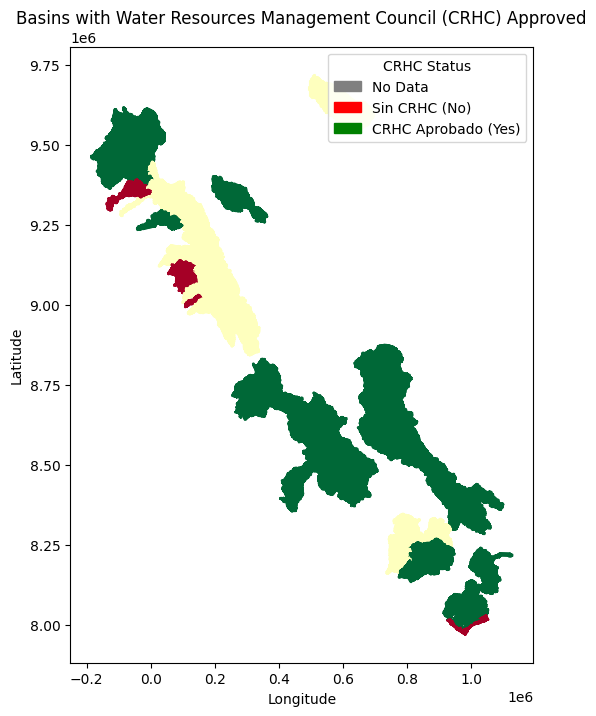

In [10]:
#PLOT RESULTS

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Plot CRHC with legend
fig, ax = plt.subplots(figsize=(10, 8))

# Fill NaN values with a placeholder value (e.g., -1) for plotting
subbasins_gdf['CRHC_plot'] = subbasins_gdf['CRHC'].fillna(-1)

# Plot with custom colors
subbasins_gdf.plot(column='CRHC_plot', ax=ax, legend=False, 
                   cmap='RdYlGn', edgecolor='face', linewidth=1.5, 
                   missing_kwds={'color': 'grey', 'edgecolor': 'grey', 'label': 'No Data'})

# Create custom legend
legend_labels = {-1: 'No Data', 0: 'Sin CRHC (No)', 1: 'CRHC Aprobado (Yes)'}
colors = {-1: 'grey', 0: 'red', 1: 'green'}

# Create patches for the legend
patches = [mpatches.Patch(color=colors[key], label=legend_labels[key]) 
           for key in sorted(legend_labels.keys())]

# Add legend
ax.legend(handles=patches, loc='upper right', title='CRHC Status')

plt.title('Basins with Water Resources Management Council (CRHC) Approved')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

SQLITE INSERT 

In [11]:
# insert results into the database 
insert_data= subbasins_gdf 
value_column= 'CRHC' 

# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Prepare list of rows to insert
rows_to_insert = []

#use unique scenario IDs
scenario_ids_unique = sorted(set(scenario_ids))

for scn_id in scenario_ids_unique:
    for _, row in insert_data.iterrows():
        comid = row['COMID']
        value = row[value_column]
        rows_to_insert.append((scn_id, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""

In [13]:
# check that min and max values match the expected range based on the Indicators Table 
indicator_limits = pd.read_sql_query(
    """
    SELECT IndID, Min, Max
    FROM Indicators
    WHERE IndID = ?
    """,
    conn,
    params=(IndID,)
)

if indicator_limits.empty:
    raise ValueError(f"No entry found in Indicators table for IndID = {IndID}")

ind_min = indicator_limits.loc[0, 'Min']
ind_max = indicator_limits.loc[0, 'Max']

print(f"Indicator {IndID}  Min: {ind_min}, Max: {ind_max}")

value_stats = (
    subbasins_gdf['CRHC']
    .agg(['min', 'max', 'count'])
    .reset_index()
)

print("\n=== Values to be inserted (by scenario) ===")
print(value_stats)

# check for duplicates 
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:")
print(df_check[duplicates])

Indicator 408  Min: 0, Max: 1

=== Values to be inserted (by scenario) ===
   index    CRHC
0    min     0.0
1    max     1.0
2  count  3533.0
Duplicates in rows_to_insert:
Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()